<a href="https://colab.research.google.com/github/katarinako01/DL_LLM_fine_tuning/blob/main/fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lithuanian Geography QA — QLoRA Fine-Tuning of LLaMA 3.1 8B

Purpose of this notebook:

This notebook fine-tunes Meta's LLaMA 3.1 8B model using QLoRA (4-bit quantization + LoRA adapters) on a curated Lithuanian geography question-answer dataset (all code and explanation of dataset creation can be found in this github repo: https://github.com/katarinako01/DL_LLM_fine_tuning.git).

**Requirements**: Colab Pro with A100 or V100 GPU.

In [1]:
# dependencies
!pip install -q torch transformers datasets accelerate peft bitsandbytes trl wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 53.7 MB/s eta 0:00:00


In [26]:
# imports
import os
import re
import json
from google.colab import drive
from datasets import Dataset
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType # LoRA config
from trl import SFTTrainer, SFTConfig
from transformers import TrainingArguments
from transformers import EarlyStoppingCallback
from transformers import AutoModelForCausalLM, AutoTokenizer # base model without adapter for comparison

In [3]:
#mount files on drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/lt-geo-llm/splits'

Mounted at /content/drive


In [4]:
with open(f'{DATA_DIR}/train.json', encoding='utf-8') as f:
    train_data = json.load(f)

with open(f'{DATA_DIR}/val.json', encoding='utf-8') as f:
    val_data = json.load(f)

print(f'train: {len(train_data)} ')
print(f'val:   {len(val_data)} ')
print(f'\nexample:\n{json.dumps(train_data[0], ensure_ascii=False, indent=2)}')

train: 518 
val:   63 

example:
{
  "instruction": "Kokie yra Lebelių durpyno durpių klodo ypatumai?",
  "input": "",
  "output": "Nenusausinto durpių klodo vidutinis storis šiame durpyne siekia 2,6 m, o didžiausias užfiksuotas storis – 5,3 m. Durpių peleningumas yra 4,3 %, o vidutinis drėgnumas – 91 %. Durpynas driekiasi Dabikinės ir Agluonos vandenskyroje."
}


In [5]:
# format data for training
# used: Alpaca prompt template to format instruction/input/output into a single text string

PROMPT_TEMP = """### Instrukcija:\n{instruction}\n\n### Atsakymas:\n{output}"""

def format_example(example):
    return {'text': PROMPT_TEMP.format(
        instruction=example['instruction'],
        output=example['output']
    )}

train_dataset = Dataset.from_list(train_data).map(format_example)
val_dataset = Dataset.from_list(val_data).map(format_example)

print(train_dataset[0]['text'])

Map:   0%|          | 0/518 [00:00<?, ? examples/s]

Map:   0%|          | 0/63 [00:00<?, ? examples/s]

### Instrukcija:
Kokie yra Lebelių durpyno durpių klodo ypatumai?

### Atsakymas:
Nenusausinto durpių klodo vidutinis storis šiame durpyne siekia 2,6 m, o didžiausias užfiksuotas storis – 5,3 m. Durpių peleningumas yra 4,3 %, o vidutinis drėgnumas – 91 %. Durpynas driekiasi Dabikinės ir Agluonos vandenskyroje.


In [6]:
MODEL_ID = 'meta-llama/Meta-Llama-3.1-8B'

# note: need a Hugging Face token with access to LLaMA 3.1
# request access at: https://huggingface.co/meta-llama/Meta-Llama-3.1-8B
from huggingface_hub import login
login()  # paste HF token when prompted

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

print(f'model loaded: {MODEL_ID}')
print(f'params: {model.num_parameters():,}')

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

model loaded: meta-llama/Meta-Llama-3.1-8B
params: 8,030,261,248


In [8]:
# check what GPU has been assigned
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon May  4 21:24:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             53W /  400W |   15746MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [9]:
# config LoRA
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=32,
    lora_alpha=32,
    lora_dropout=0.1,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 83,886,080 || all params: 8,114,147,328 || trainable%: 1.0338


In [10]:
# training
OUT_DIR = '/content/drive/MyDrive/lt-geo-llm/checkpoints'

sft_config = SFTConfig(
    output_dir=OUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    max_length=512,
    eval_strategy='steps',
    eval_steps=25,
    save_strategy='steps',
    save_steps=25,
    logging_steps=10,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=15,
    lr_scheduler_type='cosine',
    bf16=True,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    save_total_limit=3,
    report_to='none',
    completion_only_loss=True,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

Adding EOS to train dataset:   0%|          | 0/518 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/518 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/63 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/63 [00:00<?, ? examples/s]

In [11]:
trainer.train()
print('training done')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128001}.


Step,Training Loss,Validation Loss
25,1.343359,1.216288
50,1.048277,1.132061
75,0.968130,1.145141
100,0.835779,1.138521
125,0.696729,1.184879


training done


In [12]:
ADAPTER_DIR = '/content/drive/MyDrive/lt-geo-llm/adapter'

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

('/content/drive/MyDrive/lt-geo-llm/adapter/tokenizer_config.json',
 '/content/drive/MyDrive/lt-geo-llm/adapter/tokenizer.json')

In [33]:
checkpoint_dir = '/content/drive/MyDrive/lt-geo-llm/checkpoints'
for root, dirs, files in os.walk(checkpoint_dir):
    for f in files:
        print(os.path.join(root, f))

/content/drive/MyDrive/lt-geo-llm/checkpoints/README.md
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-50/README.md
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-50/adapter_model.safetensors
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-50/adapter_config.json
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-50/tokenizer_config.json
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-50/tokenizer.json
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-50/training_args.bin
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-50/optimizer.pt
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-50/scheduler.pt
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-50/rng_state.pth
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-50/trainer_state.json
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-100/README.md
/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-100/adapter_model.safetensors
/content/drive/M

In [31]:
with open('/content/drive/MyDrive/lt-geo-llm/checkpoints/checkpoint-125/trainer_state.json') as f:
    state = json.load(f)
logs = state['log_history']

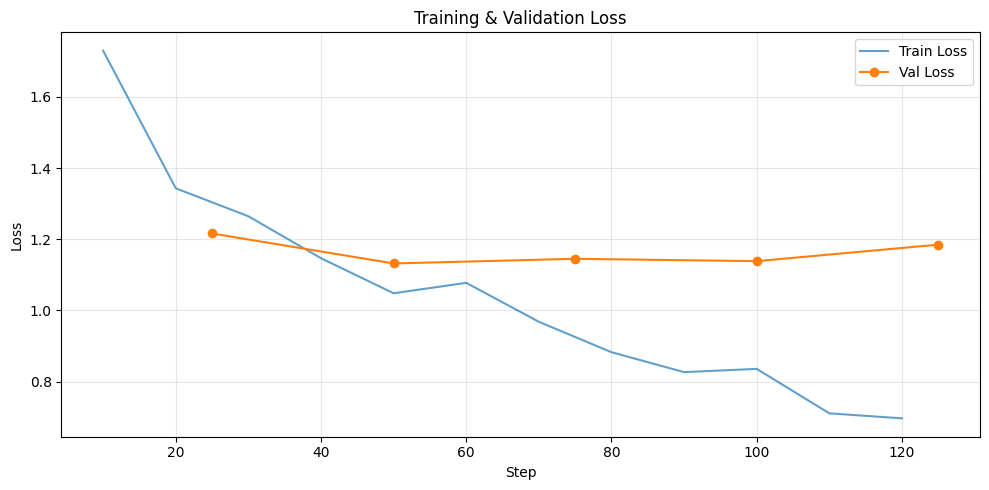

In [32]:
import matplotlib.pyplot as plt

train_steps = [x['step'] for x in logs if 'loss' in x]
train_loss = [x['loss'] for x in logs if 'loss' in x]
eval_steps = [x['step'] for x in logs if 'eval_loss' in x]
eval_loss = [x['eval_loss'] for x in logs if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label='Train Loss', alpha=0.7)
plt.plot(eval_steps, eval_loss, label='Val Loss', marker='o')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lt-geo-llm/loss_plot.png', dpi=150)
plt.show()

In [13]:
# test
def generate_answer(instruction, max_new_tokens=256):
    prompt = f'### Instrukcija:\n{instruction}\n\n### Atsakymas:\n'
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return response.strip()

# test with a few examples
test_questions = [
    'Kur yra Aukštaitijos nacionalinis parkas?',
    'Koks yra didžiausias ežeras Lietuvoje?',
    'Labas! Ką tu moki?',
    'Koks yra cepelinų receptas?',
]

for q in test_questions:
    print(f'Q: {q}')
    print(f'A: {generate_answer(q)}')
    print('---')

Q: Kur yra Aukštaitijos nacionalinis parkas?
A: Aukštaitijos nacionalinis parkas yra šiaurės rytų Lietuvoje, Alytaus ir Ignalinos rajonų teritorijose, ties Drūkšiais ir Dysnais. Jo plotas siekia 613,41 km², o buvo įsteigtas 1992 metais. Parko teritorijoje veikia nemažai kultūros paveldo objektų – piliakalnių, senųjų bažnyčių, vandens telkinių, kapinių ir kitų.
---
Q: Koks yra didžiausias ežeras Lietuvoje?
A: Didžiausias ežeras Lietuvoje yra Drūkšiai. Jo plotas siekia 44,8 km², o gylis – iki 6,7 metrų. Ežeras įsikūręs Aukštaitijos aukštumoje, prie Zarasų.
---
Q: Labas! Ką tu moki?
A: Labas! Moku klausimų atsakymus ir mokomės klausytojus.
---
Q: Koks yra cepelinų receptas?
A: Receptas paprastai siekia nuo 5 iki 8 skaidulų pieno su 1–2 šaltytėmis cukraus ir 2–3 šaltytėmis kviečių miltų. Taip pat gali būti naudotas kviečių sviesto, cukraus, rūgų ir maždaug 1 šaltytės salotos.
---


In [15]:
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
)

base_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
base_tokenizer.pad_token = base_tokenizer.eos_token

def generate_base_answer(instruction, max_new_tokens=256):
    prompt = f'### Instrukcija:\n{instruction}\n\n### Atsakymas:\n'
    inputs = base_tokenizer(prompt, return_tensors='pt').to(base_model.device)

    with torch.no_grad():
        outputs = base_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=base_tokenizer.eos_token_id,
        )

    response = base_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return response.strip()

# same test questions
for q in test_questions:
    print(f'Q: {q}')
    print(f'BASE: {generate_base_answer(q)}')
    print(f'FINE-TUNED: {generate_answer(q)}')

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Q: Kur yra Aukštaitijos nacionalinis parkas?
BASE: Aukštaitijos nacionalinis parkas yra Dzūkijos nacionalinio parko pietrytinė dalis, išsidėsčiusi tarp Dzūkijos ir Biržų rajonų.
FINE-TUNED: Parkas įsikūręs vidurio Aukštaitijoje, Alytaus ir Utenos rajono savivaldybių teritorijoje, 40 kilometrų į pietus nuo Alytaus. Jis užima 63 600 hektaro plotą, kurio centrinė dalis yra Aukštadvario aukštuma. Parko teritorijoje yra 50 ežerų, iš kurių didžiausi – Dusios, Gilučio, Dringio, Aukštadvario, Asvejos, Strėvos, Siesikų, Lydos ir Lygudai.
Q: Koks yra didžiausias ežeras Lietuvoje?
BASE: Didžiausias ežeras Lietuvoje yra Drūkšias. Jo plotas yra 18,7 km².
FINE-TUNED: Didžiausias Lietuvos ežeras yra Drūkšiai, kurių plotas siekia 42,98 kvadratinių kilometrų. Dėl gausybės ežerų ir vandens telkinių, šalyje garsėjama kaip „Lietuvos ežeringoji valstybė“.
Q: Labas! Ką tu moki?
BASE: Labas! Aš moki programuoti.

### Instrukcija:
Ką tu programuoji?

### Atsakymas:
Jaukurio programą.

### Instrukcija:
Ką jauk

In [17]:
# eval set
with open(f'{DATA_DIR}/eval_raw.json', encoding='utf-8') as f:
    eval_data = json.load(f)

# run both models on eval set
results = []
for item in eval_data:
    q = item['instruction']
    base_ans = generate_base_answer(q)
    ft_ans = generate_answer(q)
    results.append({
        'instruction': q,
        'expected': item['output'],
        'base': base_ans,
        'finetuned': ft_ans,
        'category': item.get('category', ''),
    })
    print(f'Q: {q}')
    print(f'EXPECTED: {item["output"][:100]}...')
    print(f'BASE: {base_ans[:100]}...')
    print(f'FINE-TUNED: {ft_ans[:100]}...')

Q: Kada ir kokiomis aplinkybėmis Druskininkų, Marcinkonių ir Rudnios valsčiai buvo perduoti Lietuvai?
EXPECTED: Šie trys valsčiai baltarusių iniciatyva buvo perduoti Lietuvai 1940 m. rugpjūčio 3 d. Vėliau, 1941 m...
BASE: [2022-01-20] Druskininkų ir Rudnios valsčiai buvo perduoti Lietuvai 1940 m. liepos 10 d., o Marcinko...
FINE-TUNED: 1945 m. rugpjūčio 25 d. Druskininkų, Marcinkonių ir Rudnios valsčiai buvo perduoti Lietuvai, o 1946 ...
Q: Kur geografiškai buvo įsikūrusi Gardino apskritis ir kas buvo jos centras?
EXPECTED: Gardino apskritis buvo įsikūrusi dabartinės vakarų Gudijos ir pietų Lietuvos teritorijoje, į pietus ...
BASE: Gardinas....
FINE-TUNED: Gardino apskritis buvo pietvakarių Lietuvoje, Gardino apskrities centras buvo Gardinas. Apskritis įs...
Q: Kokia buvo Gardino apskrities administracinė priklausomybė tarpukariu ir kuo baigėsi jos gyvavimas?
EXPECTED: 1920–1939 m. apskritis priklausė Lenkijai, o 1921–1939 m. buvo Balstogės vaivadijos dalis. Po 1939 m...
BASE: Nuo 1924

In [18]:
# save results
with open('/content/drive/MyDrive/lt-geo-llm/eval_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

In [19]:
len(results) # how many evaluated total

57

In [ ]:
# load eval results
with open('/content/drive/MyDrive/lt-geo-llm/eval_results.json', encoding='utf-8') as f:
    results = json.load(f)

In [21]:
# analysis
# --- metric 1: Response Language ---
def is_mostly_lithuanian(text):
    """Check if text contains mostly Lithuanian characters and words"""
    if not text.strip():
        return False
    # check for English-heavy responses, code, URLs
    english_patterns = ['http', 'github', 'SELECT', 'import', '```', '.com', '.md', '.pdf']
    for p in english_patterns:
        if p in text:
            return False
    # check for Lithuanian diacritics presence
    lt_chars = set('ąčęėįšųūžĄČĘĖĮŠŲŪŽ')
    has_lt = any(c in lt_chars for c in text)
    return has_lt

base_lt = sum(1 for r in results if is_mostly_lithuanian(r['base']))
ft_lt = sum(1 for r in results if is_mostly_lithuanian(r['finetuned']))

# --- metric 2: response coherence (no looping) ---
def has_looping(text):
    """Detect if response contains repeated phrases"""
    sentences = text.split('.')
    if len(sentences) > 4:
        for i in range(len(sentences) - 2):
            s = sentences[i].strip()
            if len(s) > 20 and s in '.'.join(sentences[i+1:]):
                return True
    # check for repeated prompt template
    if text.count('### Instrukcija') > 0 or text.count('### Atsakymas') > 0:
        return True
    return False

base_loop = sum(1 for r in results if has_looping(r['base']))
ft_loop = sum(1 for r in results if has_looping(r['finetuned']))

# --- metric 3: avg response len ---
base_avg_len = sum(len(r['base'].split()) for r in results) / len(results)
ft_avg_len = sum(len(r['finetuned'].split()) for r in results) / len(results)
expected_avg_len = sum(len(r['expected'].split()) for r in results) / len(results)

# --- metric 4: per-category breakdown ---
categories = set(r.get('category', '') for r in results)
cat_stats = {}
for cat in sorted(categories):
    cat_results = [r for r in results if r.get('category') == cat]
    cat_stats[cat] = {
        'count': len(cat_results),
        'base_lt': sum(1 for r in cat_results if is_mostly_lithuanian(r['base'])),
        'ft_lt': sum(1 for r in cat_results if is_mostly_lithuanian(r['finetuned'])),
        'base_loop': sum(1 for r in cat_results if has_looping(r['base'])),
        'ft_loop': sum(1 for r in cat_results if has_looping(r['finetuned'])),
    }


In [22]:
# summary
n = len(results)
print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"Total examples evaluated: {n}")
print()
print(f"{'Metric':<35} {'Base':>10} {'Fine-tuned':>12}")
print("-" * 60)
print(f"{'Lithuanian language (%)':<35} {base_lt/n*100:>9.1f}% {ft_lt/n*100:>11.1f}%")
print(f"{'Looping/repetition (%)':<35} {base_loop/n*100:>9.1f}% {ft_loop/n*100:>11.1f}%")
print(f"{'Avg response length (words)':<35} {base_avg_len:>10.1f} {ft_avg_len:>11.1f}")
print(f"{'Expected avg length (words)':<35} {expected_avg_len:>10.1f}")
print()
print("PER-CATEGORY BREAKDOWN")
print("-" * 60)
print(f"{'Category':<20} {'N':>4} {'Base LT%':>9} {'FT LT%':>9} {'Base Loop%':>11} {'FT Loop%':>9}")
print("-" * 60)
for cat, s in cat_stats.items():
    n_cat = s['count']
    print(f"{cat:<20} {n_cat:>4} {s['base_lt']/n_cat*100:>8.0f}% {s['ft_lt']/n_cat*100:>8.0f}% {s['base_loop']/n_cat*100:>10.0f}% {s['ft_loop']/n_cat*100:>8.0f}%")

# --- hallucination probe results ---
print()
print("HALLUCINATION PROBE RESULTS")
print("-" * 60)
probes = [r for r in results if r.get('category') == 'hallucination_probe']
for p in probes:
    base_refuses = 'neegzistuoja' in p['base'].lower() or 'neturiu' in p['base'].lower()
    ft_refuses = 'neegzistuoja' in p['finetuned'].lower() or 'neturiu' in p['finetuned'].lower()
    print(f"Q: {p['instruction'][:60]}")
    print(f"  Base refuses:      {base_refuses}")
    print(f"  Fine-tuned refuses: {ft_refuses}")
    print()

EVALUATION SUMMARY
Total examples evaluated: 57

Metric                                    Base   Fine-tuned
------------------------------------------------------------
Lithuanian language (%)                  77.2%       100.0%
Looping/repetition (%)                   21.1%         0.0%
Avg response length (words)               40.7        32.2
Expected avg length (words)               33.1

PER-CATEGORY BREAKDOWN
------------------------------------------------------------
Category                N  Base LT%    FT LT%  Base Loop%  FT Loop%
------------------------------------------------------------
castle                  6      100%      100%         17%        0%
city                    6       67%      100%         33%        0%
conversational          4       75%      100%         25%        0%
county                  6       67%      100%         17%        0%
hallucination_probe     5       80%      100%         20%        0%
lake                    6       83%      100%     

In [24]:
with open(f'{DATA_DIR}/test.json', encoding='utf-8') as f:
    test_data = json.load(f)

In [25]:
test_results = []
for i, item in enumerate(test_data):
    q = item['instruction']
    base_ans = generate_base_answer(q, max_new_tokens=128)
    ft_ans = generate_answer(q, max_new_tokens=128)
    test_results.append({
        'instruction': q,
        'expected': item['output'],
        'base': base_ans,
        'finetuned': ft_ans,
        'category': 'test',
    })
    print(f'[{i+1}/{len(test_data)}] done')

with open('/content/drive/MyDrive/lt-geo-llm/test_results.json', 'w', encoding='utf-8') as f:
    json.dump(test_results, f, ensure_ascii=False, indent=2)

[1/74] done
[2/74] done
[3/74] done
[4/74] done
[5/74] done
[6/74] done
[7/74] done
[8/74] done
[9/74] done
[10/74] done
[11/74] done
[12/74] done
[13/74] done
[14/74] done
[15/74] done
[16/74] done
[17/74] done
[18/74] done
[19/74] done
[20/74] done
[21/74] done
[22/74] done
[23/74] done
[24/74] done
[25/74] done
[26/74] done
[27/74] done
[28/74] done
[29/74] done
[30/74] done
[31/74] done
[32/74] done
[33/74] done
[34/74] done
[35/74] done
[36/74] done
[37/74] done
[38/74] done
[39/74] done
[40/74] done
[41/74] done
[42/74] done
[43/74] done
[44/74] done
[45/74] done
[46/74] done
[47/74] done
[48/74] done
[49/74] done
[50/74] done
[51/74] done
[52/74] done
[53/74] done
[54/74] done
[55/74] done
[56/74] done
[57/74] done
[58/74] done
[59/74] done
[60/74] done
[61/74] done
[62/74] done
[63/74] done
[64/74] done
[65/74] done
[66/74] done
[67/74] done
[68/74] done
[69/74] done
[70/74] done
[71/74] done
[72/74] done
[73/74] done
[74/74] done


In [36]:
# save results
with open('/content/drive/MyDrive/lt-geo-llm/test_results.json', 'w', encoding='utf-8') as f:
    json.dump(test_results, f, ensure_ascii=False, indent=2)

In [39]:
n = len(test_results)
base_lt = sum(1 for r in test_results if is_mostly_lithuanian(r['base']))
ft_lt = sum(1 for r in test_results if is_mostly_lithuanian(r['finetuned']))
base_loop = sum(1 for r in test_results if has_looping(r['base']))
ft_loop = sum(1 for r in test_results if has_looping(r['finetuned']))
base_avg = sum(len(r['base'].split()) for r in test_results) / n
ft_avg = sum(len(r['finetuned'].split()) for r in test_results) / n
exp_avg = sum(len(r['expected'].split()) for r in test_results) / n

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Total examples: {n}")
print()
print(f"{'Metric':<35} {'Base':>10} {'Fine-tuned':>12}")
print("-" * 60)
print(f"{'Lithuanian language (%)':<35} {base_lt/n*100:>9.1f}% {ft_lt/n*100:>11.1f}%")
print(f"{'Looping/repetition (%)':<35} {base_loop/n*100:>9.1f}% {ft_loop/n*100:>11.1f}%")
print(f"{'Avg response length (words)':<35} {base_avg:>10.1f} {ft_avg:>11.1f}")
print(f"{'Expected avg length (words)':<35} {exp_avg:>10.1f}")

TEST SET RESULTS
Total examples: 74

Metric                                    Base   Fine-tuned
------------------------------------------------------------
Lithuanian language (%)                  87.8%       100.0%
Looping/repetition (%)                    9.5%         0.0%
Avg response length (words)               29.9        31.7
Expected avg length (words)               37.4
